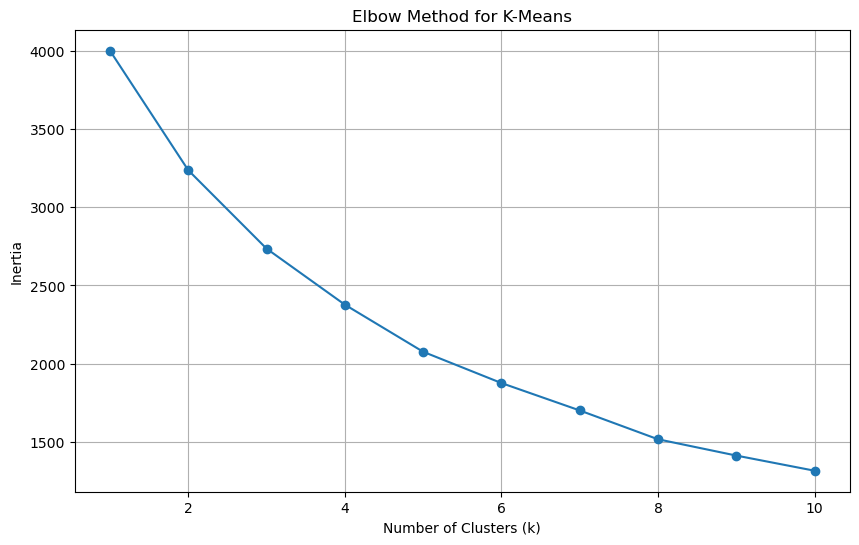


--- K-Means Clustering Results (k=3) ---
Cluster labels assigned (first 10): [2 1 2 2 1 1 2 0 0 1]...


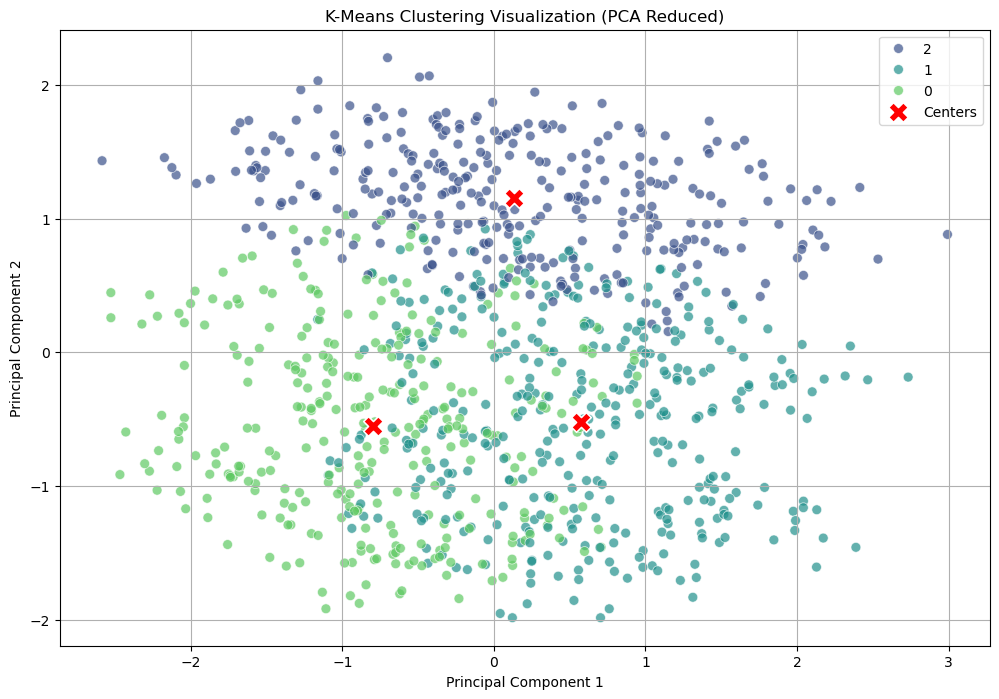


--- Cluster Interpretation ---
           duration       protocol_type           src_bytes        \
               mean count          mean count          mean count   
Cluster                                                             
0        502.801632   317      0.479495   317  23517.252366   317   
1        473.504780   367      0.520436   367  71725.841962   367   
2        498.740270   316      2.000000   316  48993.313291   316   

            dst_bytes        
                 mean count  
Cluster                      
0        20602.047319   317  
1        28414.070845   367  
2        24451.287975   316  


In [2]:
# --- Full K-Means Clustering Example --- 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Generation (Simplified) ---
np.random.seed(42)
num_samples = 1000
data_cluster = {
    'duration': np.random.uniform(1, 1000, num_samples),
    'protocol_type': np.random.randint(0, 3, num_samples),
    'src_bytes': np.random.randint(100, 100000, num_samples),
    'dst_bytes': np.random.randint(50, 50000, num_samples)
}
df_cluster_orig = pd.DataFrame(data_cluster) # Keep original for interpretation

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df_cluster_orig)

# --- Determine Optimal k (Elbow Method) ---
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_cluster_scaled)
    inertia.append(kmeans_elbow.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# --- Apply K-Means Clustering ---
k = 3 # Chosen based on Elbow Method plot
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_cluster_scaled)
cluster_labels = kmeans.labels_

# Add cluster labels to original DataFrame for interpretation
df_cluster_orig['Cluster'] = cluster_labels

print(f"\n--- K-Means Clustering Results (k={k}) ---")
print(f"Cluster labels assigned (first 10): {cluster_labels[:10]}...")

# --- Visualize Clusters ---
pca = PCA(n_components=2, random_state=42)
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

pca_df = pd.DataFrame(data=X_cluster_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = cluster_labels.astype(str)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', s=50, alpha=0.7)

cluster_centers_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(x=cluster_centers_pca[:, 0], y=cluster_centers_pca[:, 1], marker='X', s=200, color='red', label='Centers')

plt.title('K-Means Clustering Visualization (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# --- Cluster Interpretation ---
print("\n--- Cluster Interpretation ---")
print(df_cluster_orig.groupby('Cluster').agg(['mean', 'count']))